[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/planetlabs/notebooks/blob/master/jupyter-notebooks/use_cases/large_area_utilities/large_area_utilities.ipynb)

# Split Large Areas into Manageable Bounding Boxes

When you work with a large area of interest (AOI), a single request may be too large to process efficiently. A common solution is to split the AOI into smaller bounding boxes and process each subarea separately.

This notebook shows how to use utilities in `sentinelhub` to split large areas into manageable parts for download, visualization, and analysis. For installation and SDK details, see the [**Sentinel Hub Python SDK**](https://docs.planet.com/develop/sdks/#sentinel-hub-python-sdk) section in Planet Documentation.

## Prerequisites

### Imports

In [4]:
%matplotlib inline
# ruff: noqa: I001
import itertools
import tempfile
from pathlib import Path

import numpy as np
from shapely.geometry import MultiLineString, MultiPolygon, Polygon, box, shape

from sentinelhub import (
    CRS,
    BBox,
    BBoxSplitter,
    CustomGridSplitter,
    DataCollection,
    MimeType,
    MosaickingOrder,
    OsmSplitter,
    SentinelHubDownloadClient,
    SentinelHubRequest,
    TileSplitter,
    UtmGridSplitter,
    UtmZoneSplitter,
    read_data,
)

The following packages are optional. They are not required by `sentinelhub`, but this notebook uses them for visualization and raster handling. If they are not installed in your environment, install them before running the related cells.

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray  # noqa: F401 # Required for xarray.open_mfdataset() with the `rasterio` engine
import xarray as xr  # May require Dask in some environments: https://docs.dask.org/en/stable/install.html
from matplotlib.patches import Polygon as PltPolygon
from mpl_toolkits.basemap import Basemap  # Available here: https://github.com/matplotlib/basemap

### Credentials

The Sentinel Hub Python SDK requires a `client_id` and a `client_secret`. To obtain your `client_id` & `client_secret`, you need to navigate to your [account manager](https://insights.planet.com/account/), and in the **User Settings**, create a new OAuth client. More detailed instructions can be found in our [authentication documentation](https://docs.planet.com/develop/authentication/).

Once you have your `client_id` & `client_secret`, it is recommended to configure a new profile in your Sentinel Hub Python package. Instructions on how to configure your Sentinel Hub Python package can be found [in the documentation](https://sentinelhub-py.readthedocs.io/en/latest/configure.html). This is useful as changes to the config class in your notebook are usually only temporary and by saving the configuration to your profile, you don't have to generate new credentials or overwrite the default profile every time you run a new Jupyter Notebook.

The following cell checks for an existing default configuration. If none is found, you will be prompted for your credentials, which you can then optionally save.

In [8]:
from sentinelhub import SHConfig

# Authenticate with the Sentinel Hub Python SDK; See docs: https://sentinelhub-py.readthedocs.io/en/latest/configure.html and https://docs.planet.com/develop/authentication
# If no default configuration detected, enter a client ID and secret to authenticate. These can be obtained by creating an OAuth client here: https://insights.planet.com/account
config = SHConfig()
if not config.sh_client_id or not config.sh_client_secret:
    from getpass import getpass
    print('No credentials found, please provide the OAuth client ID and secret.')
    config.sh_client_id = getpass('Client ID: ')
    config.sh_client_secret = getpass('Client Secret: ')
    ## Uncomment the following lines to save your credentials to a configuration
    # config.save() 
    # print(f'Credentials saved to {SHConfig.get_config_location()}')
else:
    print(f'Using credentials stored here: {SHConfig.get_config_location()}')

No credentials found, please provide the OAuth client ID and secret.


Client ID:  ········
Client Secret:  ········


### Load the AOI

Start by loading the geometry for the area of interest. In this notebook, geometries are handled with `shapely`, so the AOI should be a `Polygon` or `MultiPolygon`.

This example uses the geometry of the [Hawaiian Islands](https://en.wikipedia.org/wiki/Hawaiian_Islands).

In [10]:
# ruff: noqa: C901

INPUT_FILE = "./pre-data/Hawaii.json"

geo_json = read_data(INPUT_FILE)
hawaii_area = shape(geo_json["features"][0]["geometry"])

type(hawaii_area)

shapely.geometry.multipolygon.MultiPolygon

The helper function below plots the AOI on a world map.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


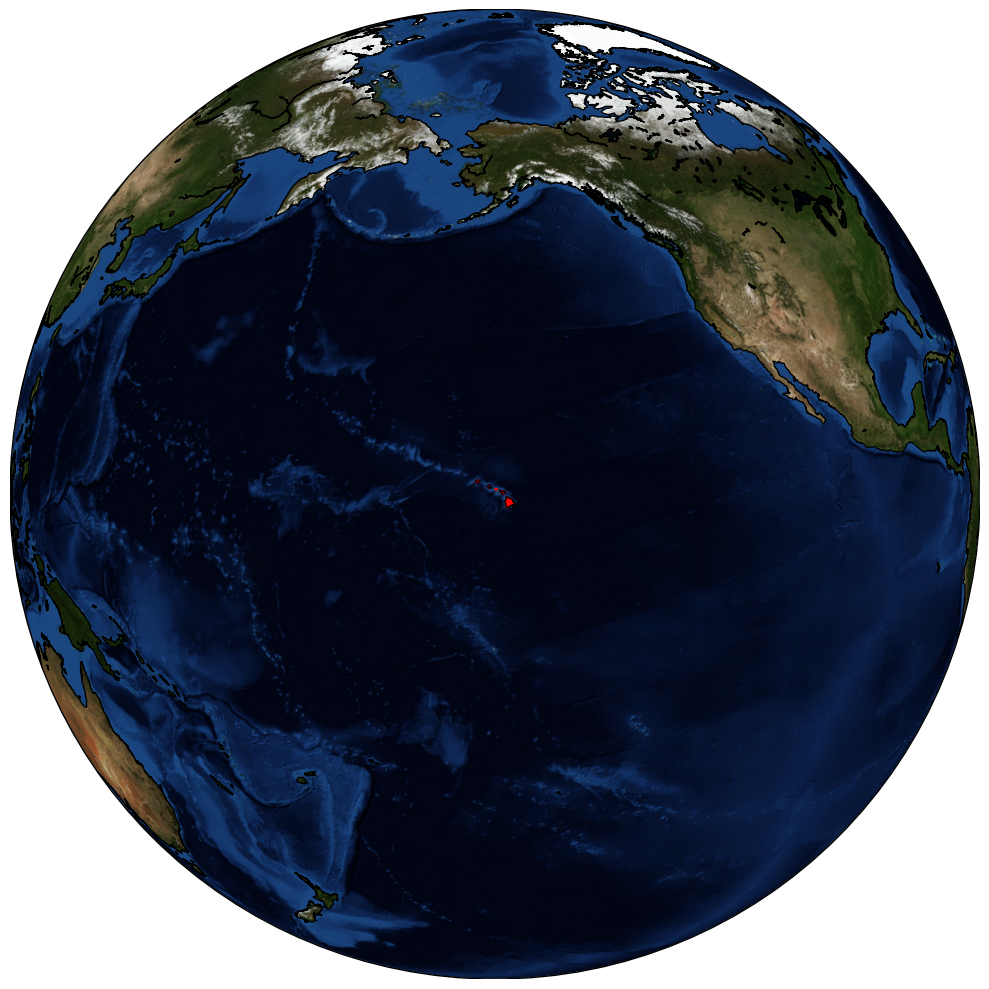

In [12]:
def show_area(area_shape):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)

    minx, miny, maxx, maxy = area_shape.bounds
    lng, lat = (minx + maxx) / 2, (miny + maxy) / 2

    m = Basemap(projection="ortho", lat_0=lat, lon_0=lng, resolution="l")
    m.drawcoastlines()
    m.bluemarble()

    if isinstance(area_shape, Polygon):
        polygon_iter = [area_shape]
    elif isinstance(area_shape, MultiPolygon):
        polygon_iter = area_shape.geoms
    else:
        raise ValueError(f"Geometry of type {type(area_shape)} is not supported")

    for polygon in polygon_iter:
        x, y = np.array(polygon.boundary.coords)[0]
        m_poly = []
        for x, y in np.array(polygon.boundary.coords):
            m_poly.append(m(x, y))
        ax.add_patch(PltPolygon(np.array(m_poly), closed=True, facecolor="red", edgecolor="red"))

    plt.tight_layout()
    plt.show()


show_area(hawaii_area)

## Split the AOI

The next step is to split the AOI into smaller bounding boxes. These smaller areas can be easier to use in downstream requests and analysis workflows.

This notebook demonstrates several different splitting strategies.

### Split the AOI into a Regular Grid

The simplest approach is to compute the AOI bounding box and divide it into equally sized cells.

`BBoxSplitter` takes a list of geometries, their CRS, and a split shape. In the example below, the bounding box is divided into a 5 × 4 grid.

In [15]:
bbox_splitter = BBoxSplitter(
    [hawaii_area], CRS.WGS84, (5, 4)
)  # bounding box will be split into grid of 5x4 bounding boxes

print("Area bounding box: {}\n".format(bbox_splitter.get_area_bbox().__repr__()))

bbox_list = bbox_splitter.get_bbox_list()
info_list = bbox_splitter.get_info_list()

print(
    "Each bounding box includes metadata about how it was created.\nExample:\nbbox: {}\ninfo: {}\n".format(
        bbox_list[0].__repr__(), info_list[0]
    )
)

Area bounding box: BBox(((-159.764448, 18.948267), (-154.807817, 22.228955)), crs=CRS('4326'))

Each bounding box includes metadata about how it was created.
Example:
bbox: BBox(((-159.764448, 21.408783), (-158.77312179999998, 22.228955)), crs=CRS('4326'))
info: {'parent_bbox': BBox(((-159.764448, 18.948267), (-154.807817, 22.228955)), crs=CRS('4326')), 'index_x': 0, 'index_y': 3}



You can also return the intersection geometry for each bounding box rather than just the bounding boxes themselves.

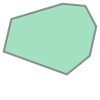

In [17]:
geometry_list = bbox_splitter.get_geometry_list()

geometry_list[0]

The helper function below visualizes the generated bounding boxes.

In [19]:
def show_splitter(splitter, alpha=0.2, area_buffer=0.2, show_legend=False):
    area_bbox = splitter.get_area_bbox()
    minx, miny, maxx, maxy = area_bbox
    lng, lat = area_bbox.middle
    w, h = maxx - minx, maxy - miny
    minx = minx - area_buffer * w
    miny = miny - area_buffer * h
    maxx = maxx + area_buffer * w
    maxy = maxy + area_buffer * h

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)

    base_map = Basemap(
        projection="mill",
        lat_0=lat,
        lon_0=lng,
        llcrnrlon=minx,
        llcrnrlat=miny,
        urcrnrlon=maxx,
        urcrnrlat=maxy,
        resolution="l",
        epsg=4326,
    )
    base_map.drawcoastlines(color=(0, 0, 0, 0))

    area_shape = splitter.get_area_shape()

    if isinstance(area_shape, Polygon):
        polygon_iter = [area_shape]
    elif isinstance(area_shape, MultiPolygon):
        polygon_iter = area_shape.geoms
    else:
        raise ValueError(f"Geometry of type {type(area_shape)} is not supported")

    for polygon in polygon_iter:
        if isinstance(polygon.boundary, MultiLineString):
            for linestring in polygon.boundary:
                ax.add_patch(PltPolygon(np.array(linestring), closed=True, facecolor=(0, 0, 0, 0), edgecolor="red"))
        else:
            ax.add_patch(
                PltPolygon(np.array(polygon.boundary.coords), closed=True, facecolor=(0, 0, 0, 0), edgecolor="red")
            )

    bbox_list = splitter.get_bbox_list()
    info_list = splitter.get_info_list()

    cm = plt.get_cmap("jet", len(bbox_list))
    legend_shapes = []
    for i, bbox in enumerate(bbox_list):
        wgs84_bbox = bbox.transform(CRS.WGS84).get_polygon()

        tile_color = tuple(list(cm(i))[:3] + [alpha])
        ax.add_patch(PltPolygon(np.array(wgs84_bbox), closed=True, facecolor=tile_color, edgecolor="green"))

        if show_legend:
            legend_shapes.append(plt.Rectangle((0, 0), 1, 1, fc=cm(i)))

    if show_legend:
        legend_names = []
        for info in info_list:
            legend_name = "{},{}".format(info["index_x"], info["index_y"])

            for prop in ["grid_index", "tile"]:
                if prop in info:
                    legend_name = "{},{}".format(info[prop], legend_name)

            legend_names.append(legend_name)

        plt.legend(legend_shapes, legend_names)
    plt.tight_layout()
    plt.show()

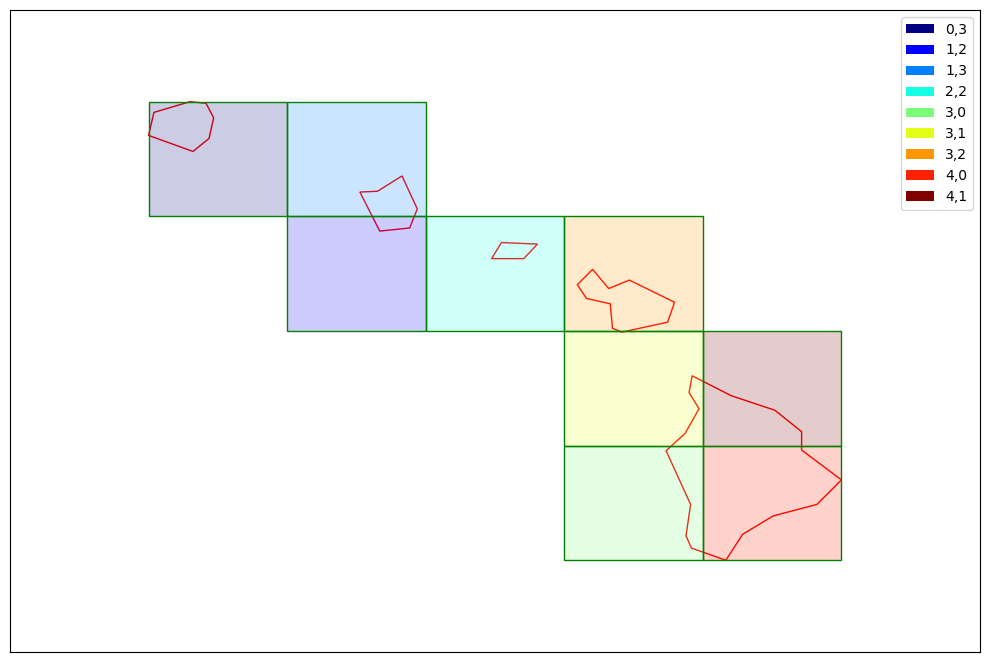

In [20]:
show_splitter(bbox_splitter, show_legend=True)

The splitter automatically removes bounding boxes that do not intersect the AOI. However, much of the remaining area inside those boxes can still fall outside the AOI.

To reduce that extra area, use the optional `reduce_bbox_sizes` parameter.

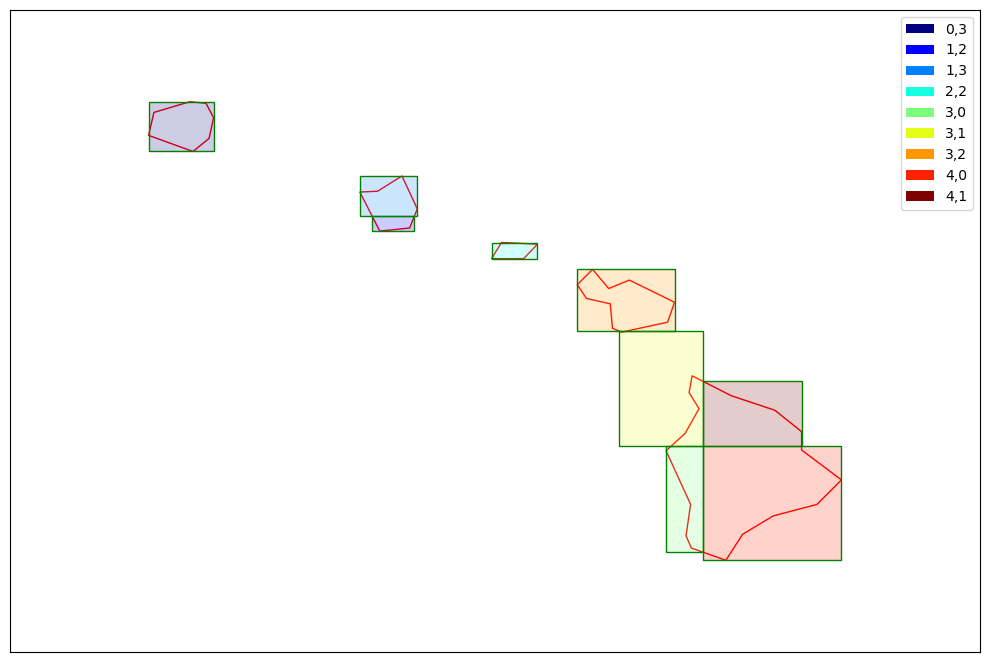

In [22]:
bbox_splitter_reduced = BBoxSplitter([hawaii_area], CRS.WGS84, (5, 4), reduce_bbox_sizes=True)

show_splitter(bbox_splitter_reduced, show_legend=True)

Using a finer grid can reduce the total extra area even further.

### Split the AOI Using the OSM Grid

In some workflows, it is useful to use a grid that stays fixed even if the AOI changes slightly.

`OsmSplitter` uses the [OpenStreetMap tile grid](https://wiki.openstreetmap.org/wiki/Slippy_Map).

In [24]:
osm_splitter = OsmSplitter([hawaii_area], CRS.WGS84, zoom_level=10)

print(repr(osm_splitter.get_bbox_list()[0]))
print(osm_splitter.get_info_list()[0])

BBox(((-159.96093749999997, 21.6165793367406), (-159.609375, 21.943045533438177)), crs=CRS('4326'))
{'zoom_level': 10, 'index_x': 57, 'index_y': 448}


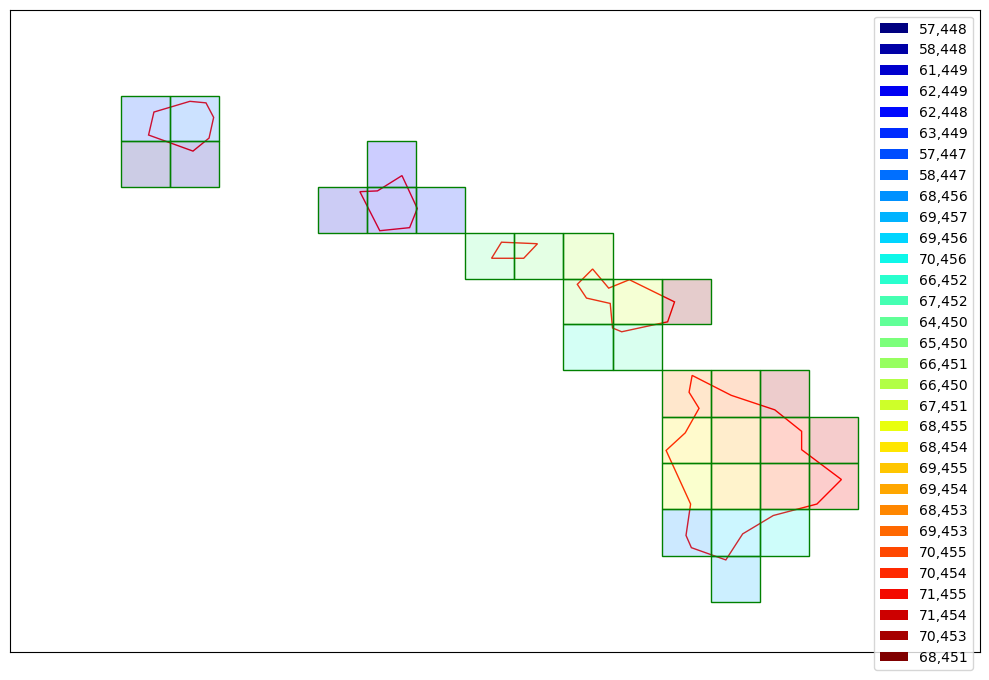

In [25]:
show_splitter(osm_splitter, show_legend=True)

### Split the AOI Using Satellite Tile Boundaries

If you want to work at the level of source satellite tiles, use `TileSplitter`. It works in combination with WFS service therefore an instance ID is required, as described in [instruction](https://sentinelhub-py.readthedocs.io/en/latest/configure.html). We also need to specify `time_interval` and `data_collection`.

In [27]:
if config.instance_id == "":
    print("Warning! To use WFS functionality, please configure the `instance_id`.")

Warning! To use WFS functionality, please configure the `instance_id`.


In [28]:
tile_splitter = TileSplitter(
    [hawaii_area], CRS.WGS84, ("2017-10-01", "2017-11-01"), data_collection=DataCollection.SENTINEL2_L1C, config=config
)

tile_bbox_list = tile_splitter.get_bbox_list()

print(len(tile_bbox_list))
print(tile_bbox_list[0].__repr__())
print(tile_splitter.get_info_list()[0])

16
BBox(((699960.0, 2290200.0), (809760.0, 2400000.0)), crs=CRS('32604'))
{'parent_bbox': BBox(((699960.0, 2290200.0), (809760.0, 2400000.0)), crs=CRS('32604')), 'index_x': 0, 'index_y': 0, 'ids': ['S2B_MSIL1C_20171028T210909_N0206_R057_T04QGJ_20171028T223108', 'S2A_MSIL1C_20171013T210921_N0205_R057_T04QGJ_20171013T210922', 'S2B_MSIL1C_20171008T210909_N0205_R057_T04QGJ_20171008T210909'], 'timestamps': [datetime.datetime(2017, 10, 28, 21, 9, 10, tzinfo=tzutc()), datetime.datetime(2017, 10, 13, 21, 9, 22, tzinfo=tzutc()), datetime.datetime(2017, 10, 8, 21, 9, 9, tzinfo=tzutc())]}


`TileSplitter` by default returns bounding boxes in the satellite tile CRS. In order to transform them we can use `BBox.transform(target_crs)` method or by specifying `crs` parameter in `get_bbox_list` method.

Note: This will only transform bounding box vertices and therefore the new bounding box will not be completely aligned with the original one. 

In [30]:
tile_splitter.get_bbox_list(crs=CRS.WGS84)[0]

BBox(((-157.08006491221116, 20.70062375217817), (-156.0067983462315, 21.676398866470976)), crs=CRS('4326'))

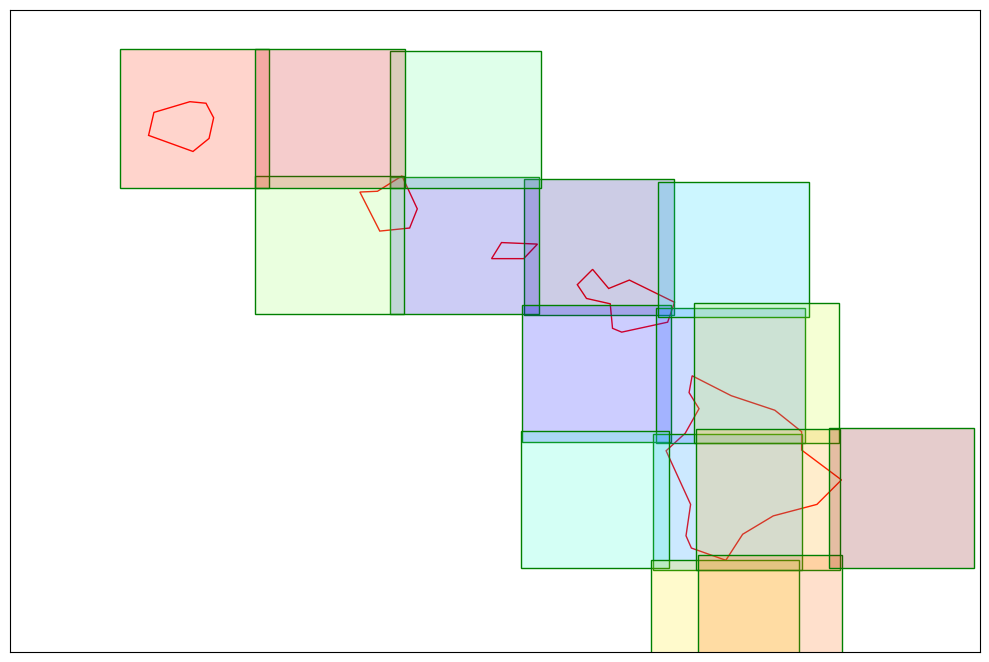

In [31]:
show_splitter(tile_splitter)

The resulting Sentinel-2 tiles can overlap. This splitter is most useful when you want to analyze data at the level of the original satellite tiles.

You can also split each satellite tile into smaller parts.

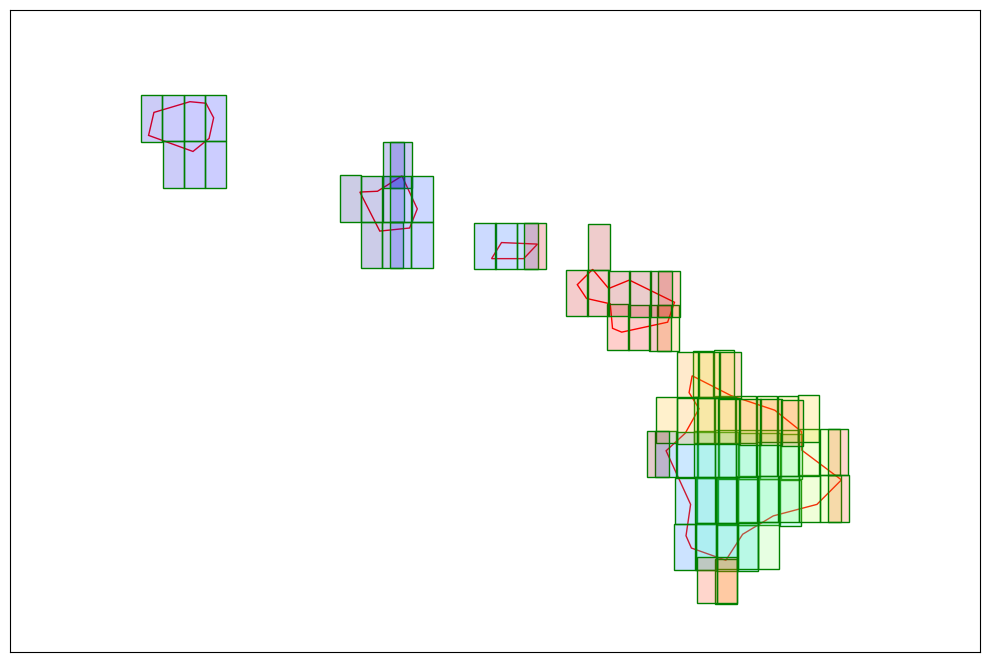

In [33]:
finer_tile_splitter = TileSplitter(
    [hawaii_area],
    CRS.WGS84,
    ("2017-10-01", "2018-03-01"),
    tile_split_shape=(7, 3),
    data_collection=DataCollection.SENTINEL2_L1C,
    config=config,
)

show_splitter(finer_tile_splitter, show_legend=False)

### Split the AOI Using a Custom Grid

If the built-in grid strategies do not match your workflow, use `CustomGridSplitter` to define your own grid from a list of bounding boxes.

The example below creates a simple grid based on integer latitude and longitude values.

In [35]:
bbox_grid = [BBox((x, y, x + 1, y + 1), CRS.WGS84) for x, y in itertools.product(range(-159, -155), range(18, 23))]

bbox_grid

[BBox(((-159.0, 18.0), (-158.0, 19.0)), crs=CRS('4326')),
 BBox(((-159.0, 19.0), (-158.0, 20.0)), crs=CRS('4326')),
 BBox(((-159.0, 20.0), (-158.0, 21.0)), crs=CRS('4326')),
 BBox(((-159.0, 21.0), (-158.0, 22.0)), crs=CRS('4326')),
 BBox(((-159.0, 22.0), (-158.0, 23.0)), crs=CRS('4326')),
 BBox(((-158.0, 18.0), (-157.0, 19.0)), crs=CRS('4326')),
 BBox(((-158.0, 19.0), (-157.0, 20.0)), crs=CRS('4326')),
 BBox(((-158.0, 20.0), (-157.0, 21.0)), crs=CRS('4326')),
 BBox(((-158.0, 21.0), (-157.0, 22.0)), crs=CRS('4326')),
 BBox(((-158.0, 22.0), (-157.0, 23.0)), crs=CRS('4326')),
 BBox(((-157.0, 18.0), (-156.0, 19.0)), crs=CRS('4326')),
 BBox(((-157.0, 19.0), (-156.0, 20.0)), crs=CRS('4326')),
 BBox(((-157.0, 20.0), (-156.0, 21.0)), crs=CRS('4326')),
 BBox(((-157.0, 21.0), (-156.0, 22.0)), crs=CRS('4326')),
 BBox(((-157.0, 22.0), (-156.0, 23.0)), crs=CRS('4326')),
 BBox(((-156.0, 18.0), (-155.0, 19.0)), crs=CRS('4326')),
 BBox(((-156.0, 19.0), (-155.0, 20.0)), crs=CRS('4326')),
 BBox(((-156.0

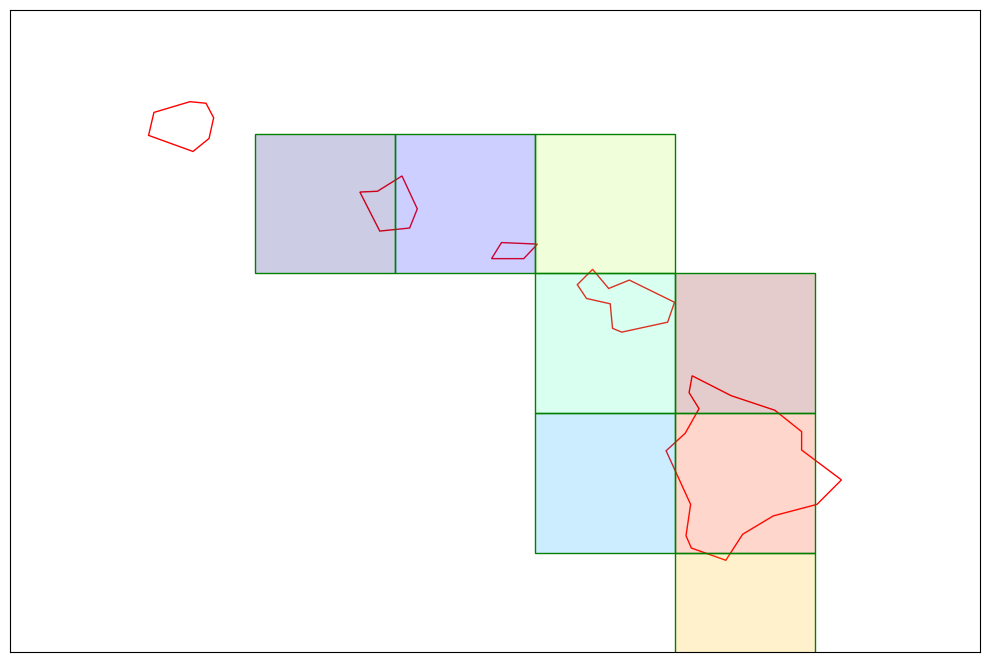

In [36]:
custom_grid_splitter = CustomGridSplitter([hawaii_area], CRS.WGS84, bbox_grid)

show_splitter(custom_grid_splitter)

Note that polygons, which are outside of the given collection of bounding boxes, will not affect the tiling.

Just like in previous examples we can further split each of the bounding boxes and reduce their size to better fit given shapes.

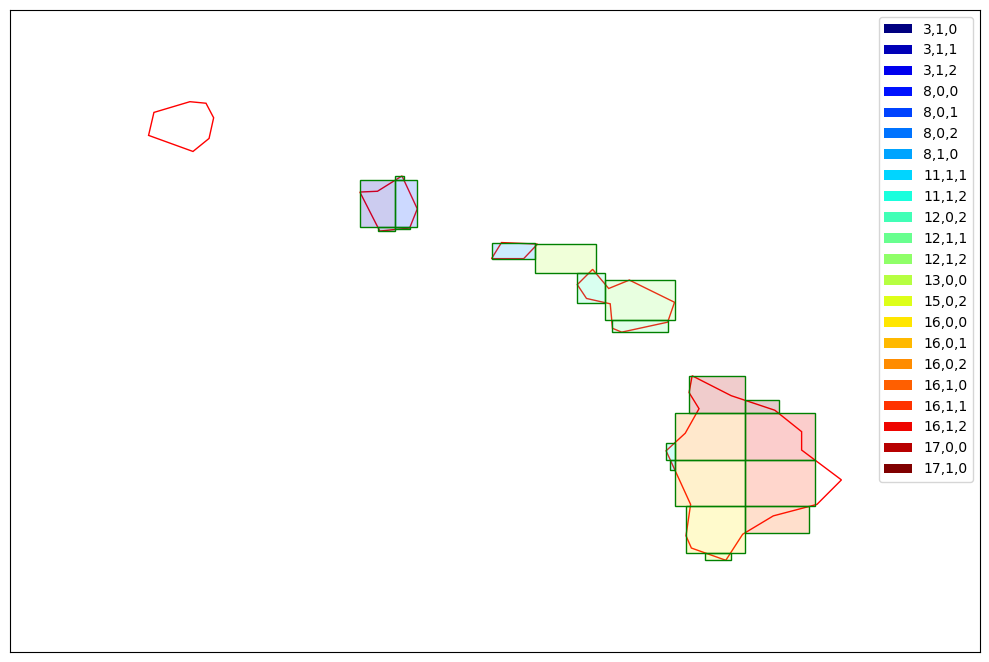

In [38]:
finer_custom_grid_splitter = CustomGridSplitter(
    [hawaii_area], CRS.WGS84, bbox_grid, bbox_split_shape=(2, 3), reduce_bbox_sizes=True
)

show_splitter(finer_custom_grid_splitter, show_legend=True)

### Split the AOI Across UTM Zones

For large areas that span multiple UTM zones, it can be useful to split the AOI by UTM zone or by UTM Military Grid Reference System.

`UtmZoneSplitter` and `UtmGridSplitter` return bounding boxes in UTM CRS. Each `BBox` uses the CRS of the UTM zone it belongs to.

Because these splitters use sizes defined in metres, `reduce_bbox_sizes` is not available for them. The two splitters return consistent results between each other, with the exceptions of areas where the UTM grid tiles present exceptions, as in `31V` and `32V`, and `31X`, `33X`, `35X` and `37X`. 

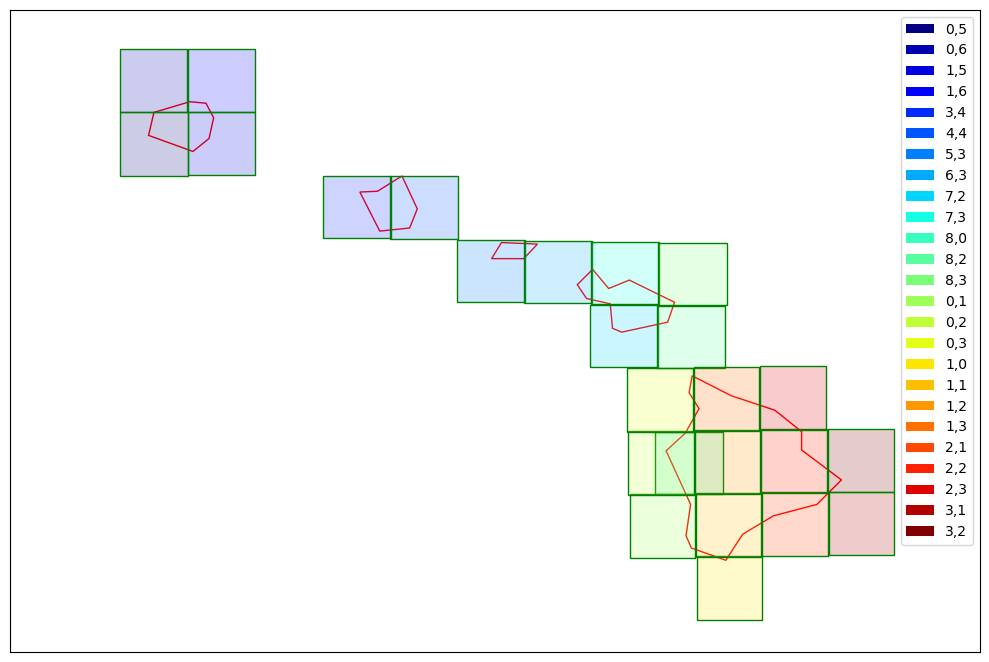

In [40]:
utm_zone_splitter = UtmZoneSplitter([hawaii_area], CRS.WGS84, (50000, 50000))

show_splitter(utm_zone_splitter, show_legend=True)

In [41]:
utm_zone_splitter.get_bbox_list()

[BBox(((400000.0, 2400000.0), (450000.0, 2450000.0)), crs=CRS('32604')),
 BBox(((400000.0, 2450000.0), (450000.0, 2500000.0)), crs=CRS('32604')),
 BBox(((450000.0, 2400000.0), (500000.0, 2450000.0)), crs=CRS('32604')),
 BBox(((450000.0, 2450000.0), (500000.0, 2500000.0)), crs=CRS('32604')),
 BBox(((550000.0, 2350000.0), (600000.0, 2400000.0)), crs=CRS('32604')),
 BBox(((600000.0, 2350000.0), (650000.0, 2400000.0)), crs=CRS('32604')),
 BBox(((650000.0, 2300000.0), (700000.0, 2350000.0)), crs=CRS('32604')),
 BBox(((700000.0, 2300000.0), (750000.0, 2350000.0)), crs=CRS('32604')),
 BBox(((750000.0, 2250000.0), (800000.0, 2300000.0)), crs=CRS('32604')),
 BBox(((750000.0, 2300000.0), (800000.0, 2350000.0)), crs=CRS('32604')),
 BBox(((800000.0, 2150000.0), (850000.0, 2200000.0)), crs=CRS('32604')),
 BBox(((800000.0, 2250000.0), (850000.0, 2300000.0)), crs=CRS('32604')),
 BBox(((800000.0, 2300000.0), (850000.0, 2350000.0)), crs=CRS('32604')),
 BBox(((150000.0, 2100000.0), (200000.0, 2150000.0)

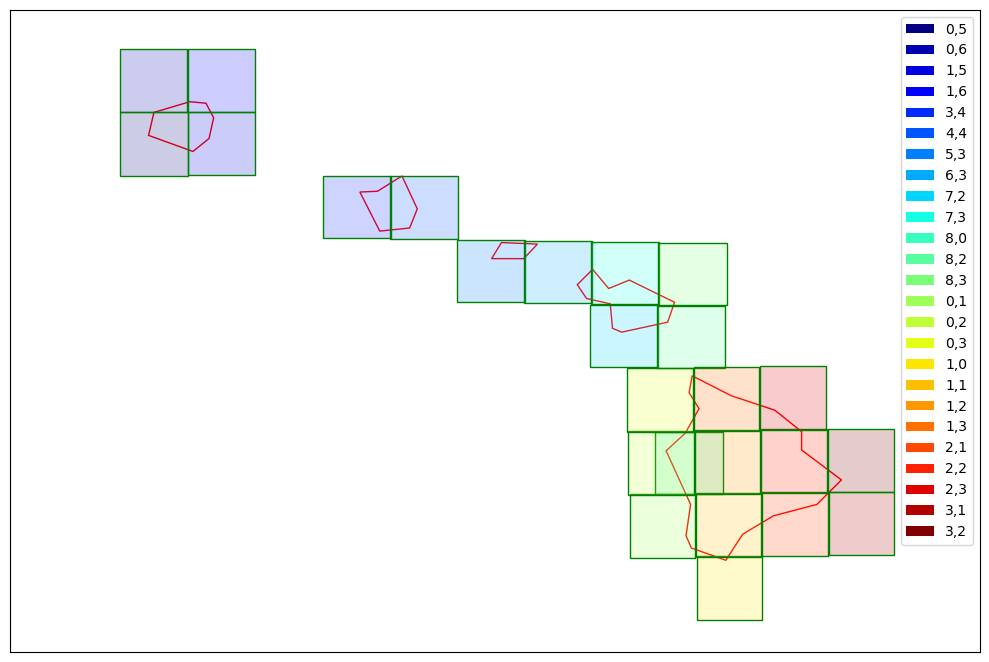

In [42]:
utm_grid_splitter = UtmGridSplitter([hawaii_area], CRS.WGS84, (50000, 50000))

show_splitter(utm_grid_splitter, show_legend=True)

### Download Data for Each Bounding Box

After splitting the AOI, you can create a request for each bounding box and download the results in parallel.

The example below uses Kauai, which is split into four bounding boxes, to demonstrate a multithreaded download workflow.

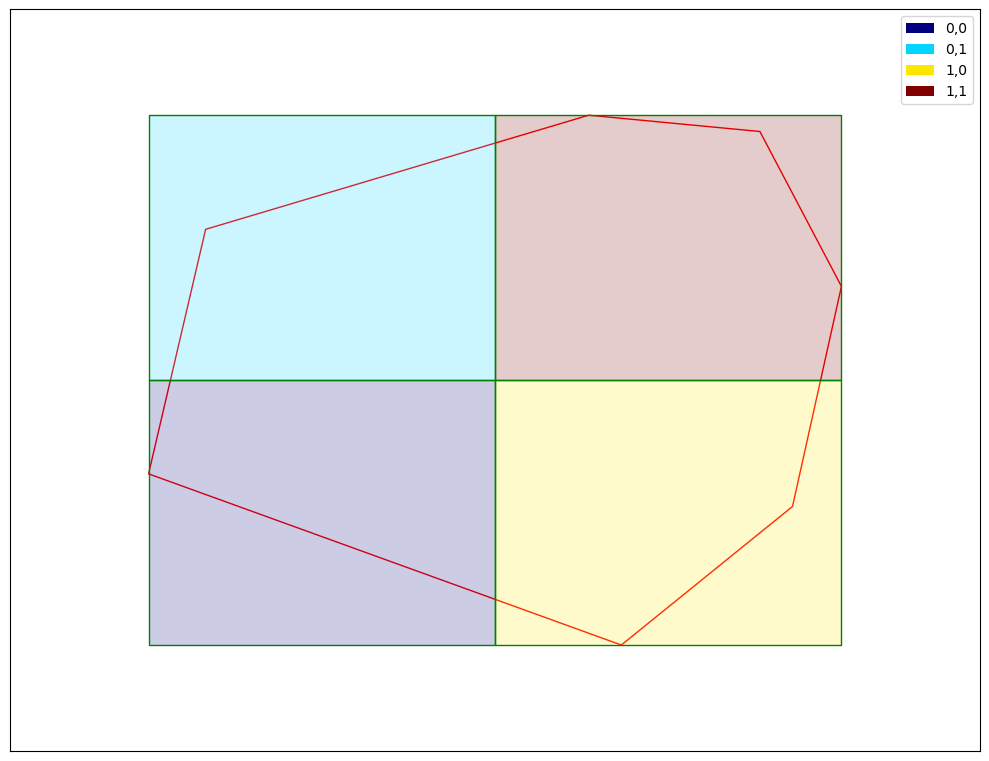

In [45]:
kauai = hawaii_area.geoms[-1]
kauai_split = BBoxSplitter([kauai], CRS.WGS84, (2, 2))
show_splitter(kauai_split, show_legend=True)

The example below uses an NDVI evalscript to request sample data.

In [47]:
ndvi_eval = """
//VERSION=3

function evaluatePixel(samples) {
    let val = index(samples.B08, samples.B04);
    return [val];
}

function setup() {
  return {
    input: [{
      bands: [
        "B04",
        "B08",
        "dataMask"
      ]
    }],
    output: {
      bands: 1
    }
  }
}
"""

The helper function below creates a `SentinelHubRequest` for a single bounding box. This is then applied to all bounding boxes, thus returning a list of `SentinelHubRequest`s each with a different specified bounding box.

The requested TIFF files are saved to a temporary folder, but you can change the output location if needed.

In [49]:
def get_subarea(bbox):
    return SentinelHubRequest(
        evalscript=ndvi_eval,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L2A,
                time_interval=("2020-10-01", "2022-10-13"),
                mosaicking_order=MosaickingOrder.LEAST_CC,
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=(1250, 1250),
        data_folder=tempfile.gettempdir(),
        config=config,
    )

In [50]:
# create a list of requests
bbox_list = kauai_split.get_bbox_list()
sh_requests = [get_subarea(bbox) for bbox in bbox_list]
dl_requests = [request.download_list[0] for request in sh_requests]

# download data with multiple threads
downloaded_data = SentinelHubDownloadClient(config=config).download(dl_requests, max_threads=5)

After the download completes, collect the file paths for the downloaded tiles.

In [52]:
data_folder = sh_requests[0].data_folder
tiffs = [Path(data_folder) / req.get_filename_list()[0] for req in sh_requests]

Next, open the tiles with `rioxarray` and mosaic them into a single image for visualization.

For larger datasets, plotting can be slow and resource-intensive. In that case, consider using GDAL tools such as `gdalbuildvrt` and `gdaladdo` to create a virtual mosaic and overviews for faster display at different scales.

In [54]:
def plot_xr_and_bboxes(data_array, geo_vector=None):
    fig, ax = plt.subplots(figsize=(10, 10))
    data_array.plot(ax=ax)
    ax.set_ylabel("Latitude")
    ax.set_xlabel("Longitude")
    ax.set_aspect(1)
    if geo_vector is not None:
        geo_vector.plot(ax=ax, edgecolor="red", facecolor="none")
    plt.show()

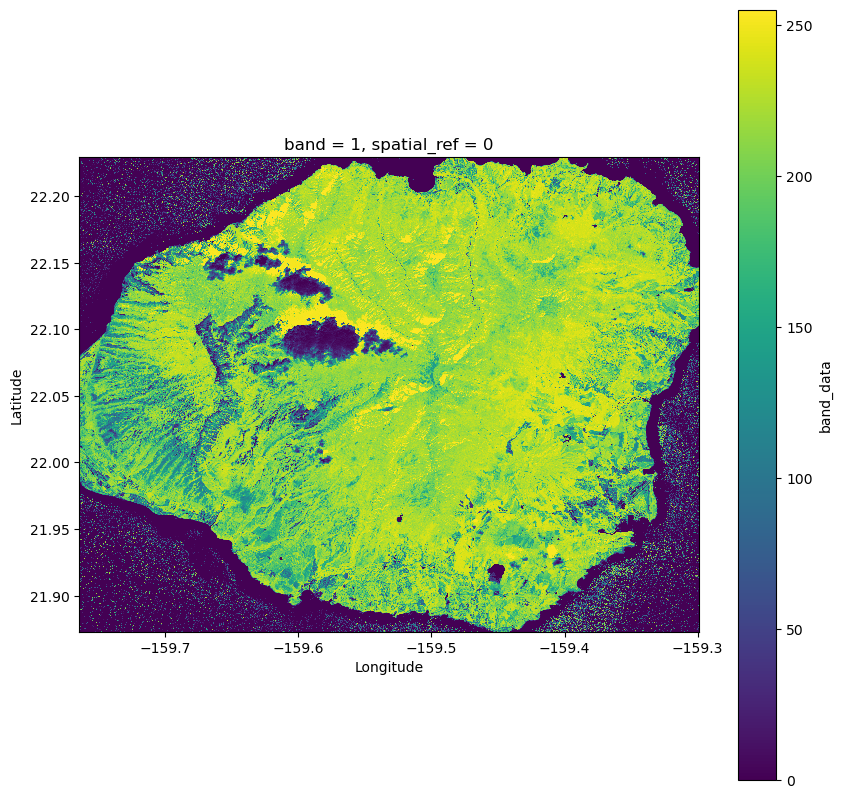

In [55]:
composed_tiff = xr.open_mfdataset(tiffs, engine="rasterio")
composed_map = composed_tiff.band_data.isel(band=0)

plot_xr_and_bboxes(composed_map)

Finally to visualize the bounding boxes as well we can draw the original bounding boxes over our raster.

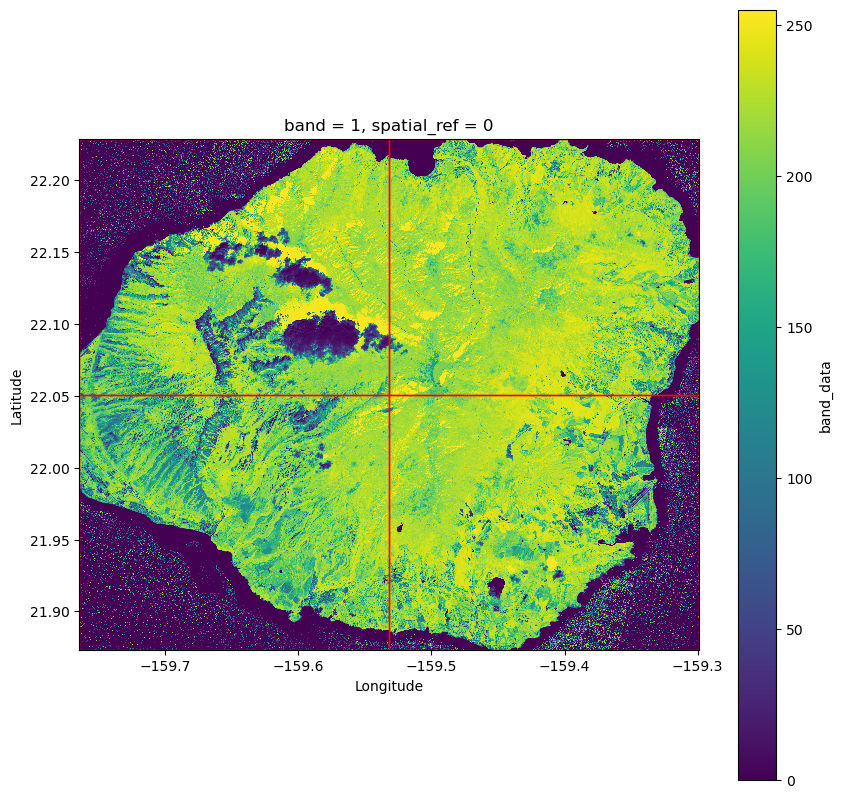

In [57]:
kauai_gpd = gpd.GeoDataFrame(geometry=[box(*bbox) for bbox in bbox_list], crs=4326)
plot_xr_and_bboxes(composed_tiff.band_data, kauai_gpd)

These tiles can also be used in downstream workflows with tools such as [eo-learn](https://eo-learn.readthedocs.io/en/latest/). For example, you can ingest them with [ImportFromTiffTask](https://eo-learn.readthedocs.io/en/latest/reference/eolearn.io.raster_io.html#eolearn.io.raster_io.ImportFromTiffTask).

This pattern is useful for larger Earth observation workflows where you need to process data in smaller, more manageable chunks.